## **A Gentle Introduction to BioPython**

**Miriam Santos** (FCUP/DCC & LIAAD)

<small><i>Algorithms for Bioinformatics & Bioinformatics 25/26</i><br>
<small><b>Note:</b> Please check the current version of Biopython and adjust the code accordingly.</i>

## **1. What is BioPython?**

**BioPython** is a Python library that provides tools for working with biological data: DNA, RNA, protein sequences, alignments, file formats, and databases. It’s one of the most widely used libraries in bioinformatics and computational biology, and is ideal for:

- Working with biological databases (like GenBank)
- Analyzing sequences
- Automating bioinformatics workflows

Below are some tasks we can perform using **BioPython**:

| Task (Example)                  | BioPython Module      |
| ------------------------------- | --------------------- |
| Read/write FASTA, GenBank files | `Bio.SeqIO`           |
| Work with DNA/protein sequences | `Bio.Seq`             |
| Calculate GC content            | `Bio.SeqUtils`        |
| Fetch data from NCBI/GenBank    | `Bio.Entrez`          |
| Align sequences (basic)         | `Bio.pairwise2`       |

### **Installation**

The easiest way to install `biopython` is using `pip` ([check here the Python version compatibility](https://pypi.org/project/biopython/)). 

You'll also need `numpy` in your environment. 

You can start by creating a new environment and installing these requirements:

```bash
conda create -n biopython-tutorial python pip
conda activate biopython-tutorial
pip install numpy biopython
```

You can test if Biopython is properly installed by executing the cell below. If no error messages appear, then everything is working and you’re all set.

**Note:** Remember to select the correct environment/kernel! (e.g., biopython-tutorial)

In [ ]:
import Bio

## **2. Working with Sequences**

### **Creating a Sequence**

Biopython provides the `Seq` class to create and manipulate sequences:

In [2]:
from Bio.Seq import Seq

my_seq = Seq("CTTCATGTGAAAGCAGACGTAAGTCA")
print(f"My Sequence: {my_seq}")

My Sequence: CTTCATGTGAAAGCAGACGTAAGTCA


### **Basic Operations with Sequences**

After having a basic sequence, we can determine the following information:

In [3]:
# Length of the sequence
print(f"Length: {len(my_seq)}")

# Occurrences of a given nucleotide
print(f"Occurrences of A: {my_seq.count("A")}")

# Slicing a sequence
print(f"Get first 3 nucleotides: {my_seq[0:3]}")

# Concatenating two sequences
add_seq = Seq("TTT")
new_seq = my_seq + add_seq
print(f"New Sequence: {new_seq}")

# Finding the starting index of a subsequence
print(f"Subsequence 'TGT' starts at index: {my_seq.find("TGT")}")

Length: 26
Occurrences of A: 9
Get first 3 nucleotides: CTT
New Sequence: CTTCATGTGAAAGCAGACGTAAGTCATTT
Subsequence 'TGT' starts at index: 5


For the most part, this information follows the standard Python functionality, but we can have more advanced use cases, using `Bio.SeqUtils`:

In [4]:
# Computing CG content
from Bio.SeqUtils import gc_fraction
print(f"GC content: {gc_fraction(my_seq)}")

# Compute molecular weight
from Bio.SeqUtils import molecular_weight
print(f"Molecular Weight: {molecular_weight(my_seq)}")

GC content: 0.4230769230769231
Molecular Weight: 8083.1774000000005


The `Seq` class itself provides several built-in functionality. [Based on the documentation provided](http://biopython.org/DIST/docs/tutorial/Tutorial-1.48.pdf), can you provide the *transcription* and *translation* of this sequence?

In [5]:
# Original Sequence
print(f"Original: {my_seq}")

# Complement
print(f"Complement: {my_seq.complement()}")

Original: CTTCATGTGAAAGCAGACGTAAGTCA
Complement: GAAGTACACTTTCGTCTGCATTCAGT


In [ ]:
# TODO: Get the reverse complement of the sequence
print(f"Transcription: {...}")

# TODO: Get the transcription of the sequence
print(f"Reverse complement: {...}")

# TODO: Get the translation of the sequence
print(f"Translation: {...}")

### **Reading from FASTA files**

Rather than creating your own sequence, you can also read it from a fasta file. The main function is `Bio.SeqIO.parse()`, which requires a filename and format and returns a `SeqRecord` iterator (in the example below we converted it to a `list`). 

- The `record.id` will return the identifier of the sequence and `record.seq` will return the sequence itself. 


In [6]:
from Bio import SeqIO

# Load all sequences from a FASTA file
fasta_path = "HMP_MOCK.V35.fasta"  # Make sure this file is in your current directory
sequences = list(SeqIO.parse(fasta_path, "fasta"))

print(f"Loaded {len(sequences)} sequences.")
for record in sequences:
    print(record.id)
    print(record.seq[:20], "...")  # Preview first 20 bases

Loaded 32 sequences.
A.baumannii.1
TGGGGAATATTGGACAATGG ...
A.odontolyticus.1
TGGGGAATATTGCACAATGG ...
B.cereus.1
TAGGGAATCTTCCGCAATGG ...
B.vulgatus.1
TGAGGAATATTGGTCAATGG ...
B.vulgatus.2
TGAGGAATATTGGTCAATGG ...
B.vulgatus.4
TGAGGAATATTGGTCAATGG ...
B.vulgatus.5
TGAGGAATATTGGTCAATGG ...
B.vulgatus.7
TGAGGAATATTGGTCAATGG ...
C.beijerinckii.1
TGGGGAATATTGCACAATGG ...
C.beijerinckii.3
TGGGGAATATTGCACAATGG ...
C.beijerinckii.4
TGGGGAATATTGCACAATGG ...
D.radiodurans.1
TTAGGAATCTTCCACAATGG ...
E.faecalis.1
TAGGGAATCTTCGGCAATGG ...
E.faecalis.2
TAGGGAATCTTCGGCAATGG ...
E.coli.1
TGGGGAATATTGCACAATGG ...
H.pylori.1
TAGGGAATATTGCTCAATGG ...
L.gasseri.1
TAGGGAATCTTCCACAATGG ...
L.monocytogenes.1
TAGGGAATCTTCCGCAATGG ...
N.meningitidis.1
TGGGGAATTTTGGACAATGG ...
P.acnes.1
TGGGGAATATTGCACAATGG ...
P.aeruginosa.1
TGGGGAATATTGGACAATGG ...
P.aeruginosa.2
TGGGGAATATTGGACAATGG ...
P.gingivalis.1
TGAGGAATATTGGTCAATGG ...
R.sphaeroides.1
TGGGGAATCTTAGACAATGG ...
S.aureus.1
TAGGGAATCTTCCGCAATGG ...
S.au

### **Writing to a new FASTA file**

`SeqIO` (Sequence Input/Output) can also be used to write sequences to files, for which the main function is `SeqIO.write()`. It allows us to save sequences as well as id or descriptions:

In [7]:
from Bio.SeqRecord import SeqRecord

new_records = [
    SeqRecord(Seq("ATGCGTAGCTA"), id="Example1", description="Synthetic gene 1"),
    SeqRecord(Seq("ATGCGTGGGTTTAA"), id="Example2", description="Synthetic gene 2")
]

# Write to file
output_file = "synthetic_genes.fasta"
SeqIO.write(new_records, output_file, "fasta")

print(f"Correctly wrote {len(new_records)} sequences to {output_file}")

Correctly wrote 2 sequences to synthetic_genes.fasta


## **3. NCBI Entrez databases**

[Entrez](https://www.ncbi.nlm.nih.gov/Web/Search/entrezfs.html) is a data retrieval system that provides users access to NCBI's databases such as PubMed, GenBank, and many others. Using Biopython's module `Bio.Entrez` allows us to access Entrez and search/download records from within a Python script:

- You must provide an email to access Entrez - NCBI can block anonymous requests (it can be a "dummy/fake" email).
- It's possible to search by keyword and define the number of identifiers returned.
- We can also retrieve a full record from Entrez, using `efetch`.
- If you fetch the record in one of the formats accepted by `Bio.SeqIO`, you could directly parse it into a `SeqRecord`.

For instance, we can get information from BRCA1 from [NCBI Genbank](https://www.ncbi.nlm.nih.gov/nuccore/NM_001407571.1). 

In [52]:
from Bio import Entrez
Entrez.email = "someemail@example.com" # Just add a random email
handle = Entrez.efetch(db="nucleotide", id="NM_001407571", rettype="gb", retmode="text")
record = SeqIO.read(handle, "genbank")
handle.close()

In [14]:
print(record.id)
print(record.name)
print(record.description)
print(record.seq)

NM_001407571.1
NM_001407571
Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant 6, mRNA
GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCGCTCAGGAGGCCTTCACCCTCTGCTCTGGGTAAAGGTAGTAGAGTCCCGGGAAAGGGACAGGGGGCCCAAGTGATGCTCTGGGGTACTGGCGTGGGAGAGTGGATTTCCGAAGCTGACAGATGGTTCATTGGAACAGAAAGAAATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTATGCAGAAAATCTTAGAGTGTCCCATCTGTCTGGAGTTGATCAAGGAACCTGTCTCCACAAAGTGTGACCACATATTTTGCAAATTTTGCATGCTGAAACTTCTCAACCAGAAGAAAGGGCCTTCACAGTGTCCTTTATGAGCCTACAAGAAAGTACGAGATTTAGTCAACTTGTTGAAGAGCTATTGAAAATCATTTGTGCTTTTCAGCTTGACACAGGTTTGGAGTATGCAAACAGCTATAATTTTGCAAAAAAGGAAAATAACTCTCCTGAACATCTAAAAGATGAAGTTTCTATCATCCAAAGTATGGGCTACAGAAACCGTGCCAAAAGACTTCTACAGAGTGAACCCGAAAATCCTTCCTTGGAAACCAGTCTCAGTGTCCAACTCTCTAACCTTGGAACTGTGAGAACTCTGAGGACAAAGCAGCGGATACAACCTCAAAAGACGTCTGTCTACATTGAATTGGGATCTGATTCTTCTGAAGATACCGTTAATAAGGCAACTTATTGCAGTGTGGGAGATCAAGAATTGTTACAAATCACCCCTCAAGGAACCAGGGATGAAATCAGTTTGGATTCTGCAAAAAAGGCTGCTTGTGAATTTTCTGAGACGGATGTAACAAATACTGAACATCATC

## **4. BLAST**

BLAST is an algorithm and program for comparing primary biological sequence information (i.e, protein or aminoacid sequences). Using Biopython, you can align sequences with Web BLAST which is the online version of BLAST, using the `Bio.Blast.NCBIWWW` module:

- Running a Web BLAST can be slower than a local BLAST, and you can create custom, personal databases to search for sequences against if running locally.
- Our BLAST output is in XML format, so we can parse the result using `NCBIXML`.

In [43]:
from Bio.Blast import NCBIWWW, NCBIXML

# Create a query sequence
query_seq = record.seq

# Submit to NCBI BLASTN (nucleotide vs. nucleotide)
result_handle = NCBIWWW.qblast("blastn", "nt", query_seq)

# Parse the result
blast_record = NCBIXML.read(result_handle)

# Print top hits
for alignment in blast_record.alignments[:1]:  # Show only top 1, change here to check for more
    print("***** Hit *****")
    print("Title:", alignment.title)
    print("Length:", alignment.length)
    for hsp in alignment.hsps[:1]:             # Check the first high-scoring pair for that alignment
        print("Score:", hsp.score)
        print("E-value:", hsp.expect)
        print("Match:", hsp.match[:75], "...")
        print("Query:", hsp.query[:75], "...")
        print("Sbjct:", hsp.sbjct[:75], "...")

***** Hit *****
Title: gi|2912989933|dbj|AP039594.1| Bradybaena similaris mixture of YIPCMo001421 and YIPCMo001540 DNA, chromosome 13, sequence
Length: 74575081
Score: 71.0
E-value: 0.000117325
Match: |||||  ||||| || || |||||  |||||  ||| |||| | |||  |  ||||| | ||||     | |||| ...
Query: ACCAAAAACCCATCCCCCAACCCAAGCCCAC--ACCCACCACCTAACATATTAACCCTCTAACCCCTATACCCAA ...
Sbjct: ACCAACCACCCACCCACCCACCCA--CCCACCAACCAACCAACCAACCAACCAACCCACCAACC-----AACCAA ...


## **5. Pairwise Sequence Alignment**

Pairwise sequence alignment methods are used to find the best-matching piecewise (local or global) alignments of two query sequences, and we can use BioPython's `Bio.pairwise2` to perform it, for instance:

- `align.globalxx`: global alignment, no scores (match = 1, mismatch = 0)
- `align.globalms`: global alignment with match/mismatch scores

Below is an example of performing global alignment using Biopython’s `pairwise2.align.globalxx`, which uses a simple match score of 1 and a mismatch score of 0.

### **Global DNA Alignment with Default Scoring**

In [ ]:
from Bio import pairwise2
from Bio. pairwise2 import format_alignment

# Perform global alignment with default scoring
alignments = pairwise2.align.globalxx("ATAGAGAATAG","ATGGCAGATAGA")

# Print the number of alignments found
print(len(alignments))

# Format and print the alignments
for a in alignments:
    print(format_alignment(*a))

7
ATAGAG-A-ATAG-
|| | | | |||| 
AT-G-GCAGATAGA
  Score=9

ATAG--AGAATAG-
|| |  || |||| 
AT-GGCAG-ATAGA
  Score=9

ATA-G-AGAATAG-
||  | || |||| 
AT-GGCAG-ATAGA
  Score=9

ATAG-AGAATAG-
||.| || |||| 
ATGGCAG-ATAGA
  Score=9

ATAG--AGAATAG-
|| |  ||| ||| 
AT-GGCAGA-TAGA
  Score=9

ATA-G-AGAATAG-
||  | ||| ||| 
AT-GGCAGA-TAGA
  Score=9

ATAG-AGAATAG-
||.| ||| ||| 
ATGGCAGA-TAGA
  Score=9



### **Global Protein Alignment with BLOSUM62 Matrix**

Now, let’s perform a global alignment using the BLOSUM62 substitution matrix, with a gap opening penalty of -4 and a gap extension penalty of -1:

In [33]:
from Bio.Align import substitution_matrices

# Load the BLOSUM62 substitution matrix
matrix = substitution_matrices.load("blosum62")

# Perform global alignment with BLOSUM62 matrix
for a in pairwise2.align.globalds("KEVLA", "EVSAW", matrix , -4, -1):
    print(format_alignment(*a))

KEVLA-
 ||.| 
-EVSAW
  Score=3



### **Local DNA Alignment**

Here is an example of a local alignment between two DNA sequences, using a match score of 3, a mismatch score of -2, and a gap penalty of -3:

In [34]:
# Perform local alignment on DNA sequences
local_dna = pairwise2.align.localms("ATAGAGAATAG", "GGGAGAATC", 3, -2, -3, -3)

# Print the local alignment results
for a in local_dna:
    print (format_alignment(*a))

4 GAGAAT
  ||||||
3 GAGAAT
  Score=18



### **Local Protein Alignment with BLOSUM62**

Here is an example of a local alignment between two protein sequences using the BLOSUM62 substitution matrix, with a gap opening penalty of -4 and a gap extension penalty of -1:

In [35]:
# Perform local alignment on protein sequences
local_prot = pairwise2.align.localds("KEVLA","EVSAW", matrix , -4, -1)

# Print the local alignment results
for a in local_prot:
    print(format_alignment(*a))

2 EVLA
  ||.|
1 EVSA
  Score=11



## **6. Multiple Sequence Alignment**

### **Running Multiple Sequence Alignment with Clustal Omega (Web API)**
In this section, we use the Clustal Omega web service (provided by EBI) to perform a real multiple sequence alignment on four protein sequences. The results are retrieved and parsed directly into BioPython for inspection.You'll need to `pip install requests` for it to work.

In [ ]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import AlignIO
from io import StringIO
import requests
import time

# Create your unaligned sequences
sequences = [
    SeqRecord(Seq("MKTAYIAKQRQISFVKSHFSRQDILRPHRTQKLFGTLTV"), id="Species_1"),
    SeqRecord(Seq("MKTAYIAKQRQISFVQSHFSRQDILRPHRTQKLFGTLTV"), id="Species_2"),
    SeqRecord(Seq("MKTAYIAKQRQISFVKSHFSRQDILRPHRTQKLFGSCTV"), id="Species_3"),
    SeqRecord(Seq("MKTAYIAKQRQISFVQSHFSRQDILRP"), id="Truncated")
]

# Convert to FASTA
fasta_io = StringIO()
SeqIO.write(sequences, fasta_io, "fasta")
fasta_str = fasta_io.getvalue()

# Submit to EBI Clustal Omega Web Service
print("Submitting to Clustal Omega at EBI...")
ebi_url = "https://www.ebi.ac.uk/Tools/services/rest/clustalo"
params = {
    "sequence": fasta_str,
    "email": "your.email@example.com",  # Use a real or dummy email
    "stype": "protein",
    "outfmt": "clustal"
}

# Submit job
response = requests.post(f"{ebi_url}/run", data=params)
job_id = response.text.strip()
print("Job ID:", job_id)

# Poll for completion
status = "RUNNING"
while status in ("RUNNING", "PENDING"):
    time.sleep(3)
    status = requests.get(f"{ebi_url}/status/{job_id}").text.strip()
print("Status:", status)

# Wait a little to ensure output is ready
time.sleep(1)

# Retrieve alignment result in Clustal format
result = requests.get(f"{ebi_url}/result/{job_id}/aln-clustal").text

# Load the aligned sequences
aligned_io = StringIO(result)
alignment = AlignIO.read(aligned_io, "clustal")

# Display the alignment
print("\n--- Multiple Sequence Alignment ---")
print(alignment)

Submitting to Clustal Omega at EBI...
Job ID: clustalo-R20250516-091233-0830-89236362-p1m
Status: FINISHED

--- Multiple Sequence Alignment ---
Alignment with 4 rows and 39 columns
MKTAYIAKQRQISFVKSHFSRQDILRPHRTQKLFGTLTV Species_1
MKTAYIAKQRQISFVQSHFSRQDILRPHRTQKLFGTLTV Species_2
MKTAYIAKQRQISFVKSHFSRQDILRPHRTQKLFGSCTV Species_3
MKTAYIAKQRQISFVQSHFSRQDILRP------------ Truncated


### **Align I/O Module**
In addition to creating alignments in code, BioPython provides the AlignIO module to handle input and output of alignment files in various formats, such as CLUSTAL, FASTA, and PHYLIP. Here is a simple example that loads an alignment in PHYLIP format and exports it to FASTA:

In [42]:
from Bio import AlignIO

# Reading an alignment file
alignment = AlignIO.read('msa.phy', 'phylip')

print ("Alignment length :", alignment.get_alignment_length ())

# Iterating through sequences in the alignment
for record in alignment:
    print(record.seq, record.id)

# Writing to FASTA format
AlignIO.write(alignment, "example_alin.fasta", "fasta")

Alignment length : 3331
CATGCTACTCCACACACCAAGCTATCTAGCCTCCCCAATCCAAAACAAACATTAAACACTTTCATCCCACGTCATAACCAATACACGCCCAAGCAGTACCCAAACATACTCCAATTCACCCACTAAACGCACACTCTTACCACGTATACCCAAAATCCCATATAGTCAACTCCACACCTCATAACCCGCCCACAATTCAGCCATCCACTAATCCCAAAAACAAAAACCTAACTACCACTAAACAACCAATACACATACCTTACGGCGACCTATCCCCCCTCCACTATAACCCAAACCACACTCCAATCAACTCCTGGCCCACCACCACATCTCACGCATTAAGCAAAATAACCTCAAGCCCCTACCACACCCCACAATCCTCAGCCTCCAATCTAACTCACACAGCCCCACCACAACATCATCACATTCCTAAAACCCCCCCCCCCCAAACCTACACACATCTCTATTTTCAACCAACCTTATCCCAAAAATACATGCATGAATCCAGTCGAACTATAAAACACAAATCCCTCACCTCCCCCAATCACCACCACTGAATTAGCACAACCTTCCATCGTCTAAACAAACCAACCGCCTATCCCTCAAAATATCCAACCTCATCACACCCACACCCACTCTCACCCATATCCAACTCCACAGCATCGCCCTACCAATCAATACACTTAAAAAAATCGTAACCTGGAACAAAAACCACGGAATACCACCCACAATAACTTCTCAAGTCCTTTCCCACTCTCCCACGTCTCAACAAAATTTCCACTGAAACCATCGCCCCACCCCCACACCTCAACGCCTCCTCCAATCCAGCACCGCCCCCAACCCCCATCAACAAACCGACTCTCTAAACGTACCTTAATAAACCGCAATCCAACAAATATCATACACTCCTAAGGACCTACTACTAACCTCGCCCAAATCAACTACCAATCTTAAACCAACAAGCCACCAGCCCACG

1

## **7. Phylogenetics**

In [39]:
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from Bio import AlignIO

# Read the sequences and align
aln = AlignIO.read('msa.phy', 'phylip')

# Print the alignment
print(aln)

Alignment with 6 rows and 3331 columns
CATGCTACTCCACACACCAAGCTATCTAGCCTCCCCAATCCAAA...ATA homo_sapie
CATACTACTCCACACACCAAACTACCTAGCCTCCCCAATCCAAA...ATA chimpanzee
CATGCTACTCCACACACCAAGCTACCTAGTCTCCCCAATCCAAA...ACA bonobo
CATACTACTCCACACACCAAATCATCTAGCCTCCCCAGTCCAGA...ACA gorilla
CATACCACTCCACACCCTATACCATCCAACTTCCCCTATCCGAA...ACA orangutan
CATATCACTCCAAACCCCAAACCATCCAGCCTCCCCAATTCAAA...ACA sumatran


In [40]:
# Calculate the distance matrix
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(aln)

# Print the distance Matrix
print('\nDistance Matrix\n===================')
print(dm)


Distance Matrix
homo_sapie  0.000000
chimpanzee  0.226959    0.000000
bonobo  0.220955    0.096968    0.000000
gorilla 0.266887    0.257881    0.249775    0.000000
orangutan   0.317322    0.321825    0.316121    0.322426    0.000000
sumatran    0.314020    0.328130    0.324227    0.328430    0.153107    0.000000
    homo_sapie  chimpanzee  bonobo  gorilla orangutan   sumatran


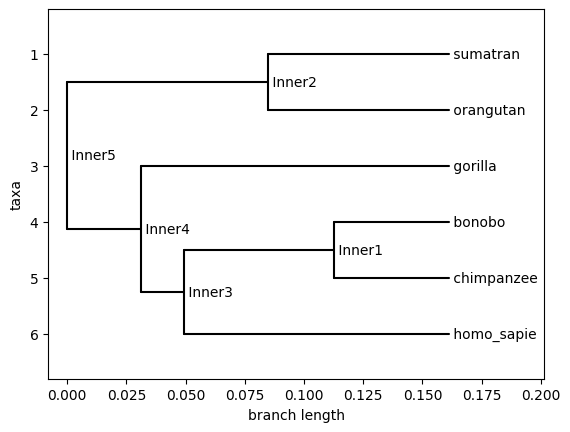


Phylogenetic Tree
                                    _______________________________ sumatran
  _________________________________|
 |                                 |_______________________________ orangutan
_|
 |            _____________________________________________________ gorilla
 |           |
 |___________|                                  ___________________ bonobo
             |        _________________________|
             |_______|                         |___________________ chimpanzee
                     |
                     |_____________________________________________ homo_sapie



In [41]:
# Construct the phylogenetic tree using UPGMA algorithm
constructor = DistanceTreeConstructor()
tree = constructor.upgma(dm)

# Draw the phylogenetic tree
Phylo.draw(tree)

# Print the phylogenetic tree in the terminal
print('\nPhylogenetic Tree\n===================')
Phylo.draw_ascii(tree)